<a href="https://colab.research.google.com/github/balrajparsi/balrajparsi/blob/main/Assignment8_ProGAN_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 8: Progressive Growing GAN (ProGAN)

**Course:** Generative AI with Large Language Models  
**Reference:** Chapter 10 - *Generative Deep Learning* (2nd Ed.), David Foster  
**Code Source:** [Paperspace ProGAN Tutorial](https://blog.paperspace.com/progan/)  
**Compatibility:** TensorFlow 2.16+ / Keras 3.x

## 0. Install Dependencies and Verify GPU

In [1]:
!pip install -q kagglehub mtcnn scikit-image

import tensorflow as tf
import keras
print(f'TensorFlow: {tf.__version__}')
print(f'Keras: {keras.__version__}')

gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs: {gpus}')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'Using GPU: {gpus[0].name}')
else:
    print('WARNING: No GPU. Go to Runtime -> Change runtime type -> GPU')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 81.5 MB/s eta 0:00:00
TensorFlow: 2.19.0
Keras: 3.13.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using GPU: /physical_device:GPU:0


In [2]:
import numpy as np
from numpy import load, asarray, zeros, ones, savez_compressed
from numpy.random import randn, randint
from math import sqrt
import os, zipfile, io
from PIL import Image

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Dense, Flatten, Reshape, Conv2D,
    UpSampling2D, AveragePooling2D, LeakyReLU, Layer, Add
)
from keras.constraints import max_norm
from keras.initializers import RandomNormal
from matplotlib import pyplot as plt
from skimage.transform import resize
from mtcnn.mtcnn import MTCNN

os.makedirs('./output', exist_ok=True)
os.makedirs('./models', exist_ok=True)
print('All imports successful.')

All imports successful.


## 1. Download Dataset and Pre-Process Data

CelebA via KaggleHub. Images are inside `archive.zip` at `celebA/000001.png`.  
We extract 10,000 faces using MTCNN.

In [3]:
import kagglehub
path = kagglehub.dataset_download('yunting0123/img-align-celeba')
print(f'Dataset path: {path}')
for item in os.listdir(path):
    fp = os.path.join(path, item)
    sz = os.path.getsize(fp)/(1024*1024) if os.path.isfile(fp) else 0
    print(f'  {item}' + (f' ({sz:.1f} MB)' if sz > 0 else '/'))

100%|██████████| 246M/246M [00:02<00:00, 93.9MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/yunting0123/img-align-celeba/versions/1
  t/


In [4]:
def extract_face(detector, pixels, required_size=(128,128)):
    faces = detector.detect_faces(pixels)
    if len(faces) == 0: return None
    x1,y1,w,h = faces[0]['box']
    x1,y1 = abs(x1),abs(y1)
    face = pixels[y1:y1+h, x1:x1+w]
    img = Image.fromarray(face).resize(required_size)
    return asarray(img)

def load_faces_from_zip(zip_path, n_faces=10000):
    detector = MTCNN()
    faces = []
    with zipfile.ZipFile(zip_path, 'r') as zf:
        img_files = sorted([f for f in zf.namelist()
                           if f.lower().endswith(('.png','.jpg','.jpeg'))
                           and not f.startswith('__')])
        print(f'Found {len(img_files)} images in archive')
        for i, fname in enumerate(img_files):
            try:
                img = Image.open(io.BytesIO(zf.read(fname))).convert('RGB')
                face = extract_face(detector, asarray(img))
                if face is not None: faces.append(face)
                if len(faces) % 500 == 0 and faces:
                    print(f'  {len(faces)} faces (scanned {i+1})...')
                if len(faces) >= n_faces: break
            except: continue
    return asarray(faces)

# Find zip and extract
zip_file = None
for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith('.zip'):
            zip_file = os.path.join(root, f); break
    if zip_file: break

if zip_file:
    print(f'Found: {zip_file}')
    all_faces = load_faces_from_zip(zip_file, 10000)
else:
    # Fallback: look for extracted images
    detector = MTCNN(); faces = []
    for root, dirs, files in os.walk(path):
        imgs = [f for f in files if f.lower().endswith(('.png','.jpg'))]
        if len(imgs) > 100:
            for fname in sorted(imgs):
                try:
                    img = Image.open(os.path.join(root,fname)).convert('RGB')
                    face = extract_face(detector, asarray(img))
                    if face is not None: faces.append(face)
                    if len(faces) % 500 == 0 and faces: print(f'  {len(faces)}...')
                    if len(faces) >= 10000: break
                except: continue
            break
    all_faces = asarray(faces)

print(f'Total faces: {all_faces.shape}')
savez_compressed('img_align_celeba_128.npz', all_faces)
print('Saved.')

  500...
  1000...
  1500...
  2000...
  2500...
  3000...
  3500...
  4000...
  4500...
  5000...
  5500...
  6000...
  6500...
  7000...
  7500...
  8000...
  8500...
  9000...
  9500...
  10000...
Total faces: (10000, 128, 128, 3)
Saved.


Loaded: (10000, 128, 128, 3)


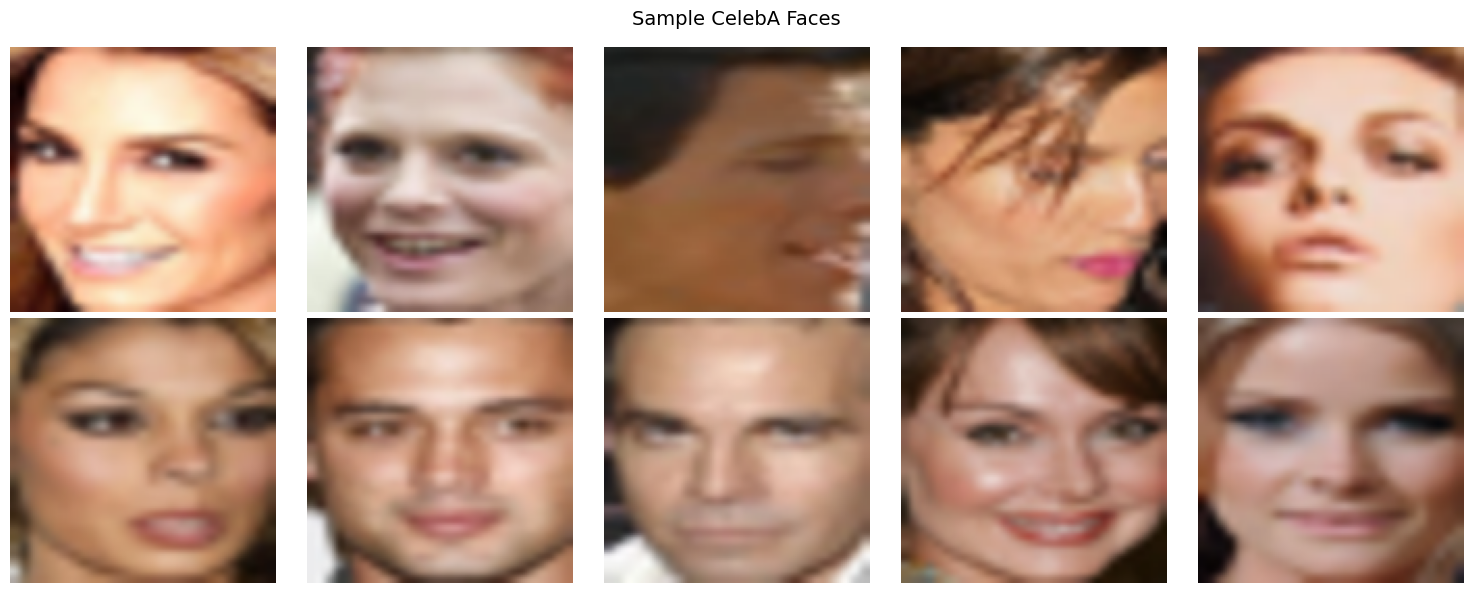

In [5]:
data = load('img_align_celeba_128.npz')
faces = data['arr_0']
print(f'Loaded: {faces.shape}')

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(faces[i]); ax.axis('off')
plt.suptitle('Sample CelebA Faces', fontsize=14)
plt.tight_layout(); plt.savefig('./output/training_samples.png', dpi=100)
plt.show()

## 2. Building Essential Functions (Keras 3 Compatible)

All `keras.backend` calls replaced with `tf.*` equivalents for Keras 3 compatibility.

In [6]:
# ============================================================
# PixelNormalization - Keras 3 compatible
# Uses tf.* instead of keras.backend.*
# ============================================================
class PixelNormalization(Layer):
    def __init__(self, **kwargs):
        super(PixelNormalization, self).__init__(**kwargs)

    def call(self, inputs):
        mean_sq = tf.reduce_mean(tf.square(inputs), axis=-1, keepdims=True)
        return inputs / tf.sqrt(mean_sq + 1e-8)

    def compute_output_shape(self, input_shape):
        return input_shape

# ============================================================
# MinibatchStdev - Keras 3 compatible
# ============================================================
class MinibatchStdev(Layer):
    def __init__(self, **kwargs):
        super(MinibatchStdev, self).__init__(**kwargs)

    def call(self, inputs):
        mean = tf.reduce_mean(inputs, axis=0, keepdims=True)
        mean_sq_diff = tf.reduce_mean(tf.square(inputs - mean), axis=0, keepdims=True)
        stdev = tf.sqrt(mean_sq_diff + 1e-8)
        mean_pix = tf.reduce_mean(stdev, keepdims=True)
        shape = tf.shape(inputs)
        output = tf.tile(mean_pix, [shape[0], shape[1], shape[2], 1])
        return tf.concat([inputs, output], axis=-1)

    def compute_output_shape(self, input_shape):
        s = list(input_shape)
        s[-1] += 1
        return tuple(s)

# ============================================================
# WeightedSum - Keras 3 compatible
# Uses tf.Variable instead of backend.variable
# ============================================================
class WeightedSum(Add):
    def __init__(self, alpha=0.0, **kwargs):
        super(WeightedSum, self).__init__(**kwargs)
        self.alpha = tf.Variable(alpha, dtype=tf.float32,
                                 trainable=False, name='ws_alpha')

    def _merge_function(self, inputs):
        assert len(inputs) == 2
        return ((1.0 - self.alpha) * inputs[0]) + (self.alpha * inputs[1])

# ============================================================
# Wasserstein loss
# ============================================================
def wasserstein_loss(y_true, y_pred):
    return tf.reduce_mean(y_true * y_pred)

print('Custom layers defined (Keras 3 compatible).')

Custom layers defined (Keras 3 compatible).


In [15]:
# ============================================================
# Utility functions
# ============================================================
def load_real_samples(filename):
    X = load(filename)['arr_0'].astype('float32')
    return (X - 127.5) / 127.5

def generate_real_samples(dataset, n_samples):
    ix = randint(0, dataset.shape[0], n_samples)
    return dataset[ix], ones((n_samples, 1))

def generate_latent_points(latent_dim, n_samples):
    return randn(latent_dim * n_samples).reshape(n_samples, latent_dim)

def generate_fake_samples(generator, latent_dim, n_samples):
    z = generate_latent_points(latent_dim, n_samples)
    return generator.predict(z, verbose=0), -ones((n_samples, 1))

def update_fadein(models, step, n_steps):
    alpha = step / float(n_steps - 1)
    for model in models:
        for layer in model.layers:
            if isinstance(layer, WeightedSum):
                layer.alpha.assign(alpha)

def scale_dataset(images, new_shape):
    images_list = []
    for image in images:
        img_01 = (image + 1.0) / 2.0
        new_image = resize(img_01, new_shape, 0)
        new_image = (new_image * 2.0) - 1.0
        images_list.append(new_image)
    return asarray(images_list).astype('float32')

print('Utilities defined.')

Utilities defined.


## 3. Create the Generator Network

Progressive blocks: 4x4 -> 8x8 -> 16x16 -> 32x32 -> 64x64  
Uses `UpSampling2D(size=(2,2))` + Conv2D + PixelNorm + LeakyReLU

In [16]:
def add_generator_block(old_model):
    init = RandomNormal(stddev=0.02)
    const = max_norm(1.0)
    block_end = old_model.layers[-2].output

    upsampling = UpSampling2D(size=(2, 2))(block_end)
    g = Conv2D(128, (3,3), padding='same', kernel_initializer=init,
               kernel_constraint=const)(upsampling)
    g = PixelNormalization()(g)
    g = LeakyReLU(negative_slope=0.2)(g)
    g = Conv2D(128, (3,3), padding='same', kernel_initializer=init,
               kernel_constraint=const)(g)
    g = PixelNormalization()(g)
    g = LeakyReLU(negative_slope=0.2)(g)

    out_image = Conv2D(3, (1,1), padding='same', kernel_initializer=init,
                       kernel_constraint=const)(g)
    model1 = Model(old_model.input, out_image)

    out_old = old_model.layers[-1]
    out_image2 = out_old(upsampling)
    merged = WeightedSum()([out_image2, out_image])
    model2 = Model(old_model.input, merged)
    return [model1, model2]

def define_generator(latent_dim, n_blocks, in_dim=4):
    init = RandomNormal(stddev=0.02)
    const = max_norm(1.0)
    model_list = []

    in_latent = Input(shape=(latent_dim,))
    g = Dense(128 * in_dim * in_dim, kernel_initializer=init,
              kernel_constraint=const)(in_latent)
    g = Reshape((in_dim, in_dim, 128))(g)
    g = Conv2D(128, (3,3), padding='same', kernel_initializer=init,
               kernel_constraint=const)(g)
    g = PixelNormalization()(g)
    g = LeakyReLU(negative_slope=0.2)(g)
    g = Conv2D(128, (3,3), padding='same', kernel_initializer=init,
               kernel_constraint=const)(g)
    g = PixelNormalization()(g)
    g = LeakyReLU(negative_slope=0.2)(g)
    out_image = Conv2D(3, (1,1), padding='same', kernel_initializer=init,
                       kernel_constraint=const)(g)
    model = Model(in_latent, out_image)
    model_list.append([model, model])

    for i in range(1, n_blocks):
        old_model = model_list[i - 1][0]
        models = add_generator_block(old_model)
        model_list.append(models)

    return model_list

print('Generator defined.')

Generator defined.


## 4. Create the Discriminator Network

In [17]:
def add_discriminator_block(old_model, n_input_layers=3):
    init = RandomNormal(stddev=0.02)
    const = max_norm(1.0)
    in_shape = list(old_model.input.shape)
    input_shape = (in_shape[-2]*2, in_shape[-2]*2, in_shape[-1])
    in_image = Input(shape=input_shape)

    d = Conv2D(128, (1,1), padding='same', kernel_initializer=init,
               kernel_constraint=const)(in_image)
    d = LeakyReLU(negative_slope=0.2)(d)
    d = Conv2D(128, (3,3), padding='same', kernel_initializer=init,
               kernel_constraint=const)(d)
    d = LeakyReLU(negative_slope=0.2)(d)
    d = Conv2D(128, (3,3), padding='same', kernel_initializer=init,
               kernel_constraint=const)(d)
    d = LeakyReLU(negative_slope=0.2)(d)
    d = AveragePooling2D(pool_size=(2, 2))(d)
    block_new = d

    for i in range(n_input_layers, len(old_model.layers)):
        d = old_model.layers[i](d)
    model1 = Model(in_image, d)

    downsample = AveragePooling2D(pool_size=(2, 2))(in_image)
    block_old = old_model.layers[1](downsample)
    block_old = old_model.layers[2](block_old)
    d = WeightedSum()([block_old, block_new])
    for i in range(n_input_layers, len(old_model.layers)):
        d = old_model.layers[i](d)
    model2 = Model(in_image, d)
    return [model1, model2]

def define_discriminator(n_blocks, input_shape=(4,4,3)):
    init = RandomNormal(stddev=0.02)
    const = max_norm(1.0)
    model_list = []

    in_image = Input(shape=input_shape)
    d = Conv2D(128, (1,1), padding='same', kernel_initializer=init,
               kernel_constraint=const)(in_image)
    d = LeakyReLU(negative_slope=0.2)(d)
    d = MinibatchStdev()(d)
    d = Conv2D(128, (3,3), padding='same', kernel_initializer=init,
               kernel_constraint=const)(d)
    d = LeakyReLU(negative_slope=0.2)(d)
    d = Flatten()(d)
    d = Dense(1)(d)
    model = Model(in_image, d)
    model.compile(loss=wasserstein_loss, optimizer=Adam(
        learning_rate=0.001, beta_1=0, beta_2=0.99, epsilon=10e-8))
    model_list.append([model, model])

    for i in range(1, n_blocks):
        old_model = model_list[i-1][0]
        models = add_discriminator_block(old_model)
        models[0].compile(loss=wasserstein_loss, optimizer=Adam(
            learning_rate=0.001, beta_1=0, beta_2=0.99, epsilon=10e-8))
        models[1].compile(loss=wasserstein_loss, optimizer=Adam(
            learning_rate=0.001, beta_1=0, beta_2=0.99, epsilon=10e-8))
        model_list.append(models)

    return model_list

print('Discriminator defined.')

Discriminator defined.


## 5. ProGAN Model Architecture and Training Loop

In [18]:
def define_composite(discriminators, generators):
    model_list = []
    for i in range(len(discriminators)):
        g_models, d_models = generators[i], discriminators[i]
        d_models[0].trainable = False
        model1 = Sequential([g_models[0], d_models[0]])
        model1.compile(loss=wasserstein_loss, optimizer=Adam(
            learning_rate=0.001, beta_1=0, beta_2=0.99, epsilon=10e-8))
        d_models[1].trainable = False
        model2 = Sequential([g_models[1], d_models[1]])
        model2.compile(loss=wasserstein_loss, optimizer=Adam(
            learning_rate=0.001, beta_1=0, beta_2=0.99, epsilon=10e-8))
        model_list.append([model1, model2])
    return model_list

def train_epochs(g_model, d_model, gan_model, dataset, n_epochs,
                 n_batch, latent_dim, fadein=False):
    bat_per_epo = int(dataset.shape[0] / n_batch)
    n_steps = bat_per_epo * n_epochs
    half_batch = int(n_batch / 2)
    for i in range(n_steps):
        if fadein:
            update_fadein([g_model, d_model, gan_model], i, n_steps)
        X_real, y_real = generate_real_samples(dataset, half_batch)
        X_fake, y_fake = generate_fake_samples(g_model, latent_dim, half_batch)
        d1 = d_model.train_on_batch(X_real, y_real)
        d2 = d_model.train_on_batch(X_fake, y_fake)
        z = generate_latent_points(latent_dim, n_batch)
        g_loss = gan_model.train_on_batch(z, ones((n_batch, 1)))
        if (i+1) % bat_per_epo == 0:
            ep = (i+1)//bat_per_epo
            print(f'  Epoch {ep}/{n_epochs} | d_real={d1:.3f} d_fake={d2:.3f} g={g_loss:.3f}')

def summarize_performance(status, g_model, latent_dim, n_samples=25):
    gen_shape = g_model.output_shape
    name = f'{gen_shape[1]}x{gen_shape[2]}-{status}'
    X, _ = generate_fake_samples(g_model, latent_dim, n_samples)
    X = (X - X.min()) / (X.max() - X.min())
    sq = int(sqrt(n_samples))
    fig, axes = plt.subplots(sq, sq, figsize=(10, 10))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(X[i]); ax.axis('off')
    plt.suptitle(f'Generated Faces - {name}', fontsize=14, fontweight='bold')
    fn = f'./output/generated_{name}.png'
    plt.savefig(fn, dpi=150, bbox_inches='tight'); plt.show()
    print(f'> Saved {fn}')

def train(g_models, d_models, gan_models, dataset, latent_dim,
          e_norm, e_fadein, n_batch):
    g_n, d_n, gan_n = g_models[0][0], d_models[0][0], gan_models[0][0]
    gen_shape = g_n.output_shape
    scaled = scale_dataset(dataset, gen_shape[1:])
    print(f'\n{"="*60}\nStage 1: {gen_shape[1]}x{gen_shape[2]} | data: {scaled.shape}\n{"="*60}')
    train_epochs(g_n, d_n, gan_n, scaled, e_norm[0], n_batch[0], latent_dim)
    summarize_performance('tuned', g_n, latent_dim)

    for i in range(1, len(g_models)):
        [g_n, g_f] = g_models[i]
        [d_n, d_f] = d_models[i]
        [gan_n, gan_f] = gan_models[i]
        gen_shape = g_n.output_shape
        scaled = scale_dataset(dataset, gen_shape[1:])
        print(f'\n{"="*60}\nStage {i+1}: {gen_shape[1]}x{gen_shape[2]} | data: {scaled.shape}\n{"="*60}')
        print('--- Fade-in ---')
        train_epochs(g_f, d_f, gan_f, scaled, e_fadein[i], n_batch[i], latent_dim, fadein=True)
        summarize_performance('faded', g_f, latent_dim)
        print('--- Tuning ---')
        train_epochs(g_n, d_n, gan_n, scaled, e_norm[i], n_batch[i], latent_dim)
        summarize_performance('tuned', g_n, latent_dim)

print('Training pipeline defined.')

Training pipeline defined.


## 6. Execute Training

In [19]:
latent_dim = 100
n_blocks = 5  # 4x4 -> 8x8 -> 16x16 -> 32x32 -> 64x64

print('Building models...')
d_models = define_discriminator(n_blocks)
g_models = define_generator(latent_dim, n_blocks)
gan_models = define_composite(d_models, g_models)
print(f'Built {n_blocks} stages.')
g_models[-1][0].summary()

Building models...
Built 5 stages.


Model: "functional_44"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2048)           │       206,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pixel_normalization_10          │ (None, 4, 4, 128)      │             0 │
│ (PixelNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_38 (LeakyReLU)      │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pixel_normalization_11          │ (None, 4, 4, 128)      │             0 │
│ (PixelNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_39 (LeakyReLU)      │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pixel_normalization_12          │ (None, 8, 8, 128)      │             0 │
│ (PixelNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_40 (LeakyReLU)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pixel_normalization_13          │ (None, 8, 8, 128)      │             0 │
│ (PixelNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_41 (LeakyReLU)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pixel_normalization_14          │ (None, 16, 16, 128)    │             0 │
│ (PixelNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_42 (LeakyReLU)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pixel_normalization_15          │ (None, 16, 16, 128)    │             0 │
│ (PixelNormalization)            │                        │             

 Total params: 1,683,075 (6.42 MB)

 Trainable params: 1,683,075 (6.42 MB)

 Non-trainable params: 0 (0.00 B)

Dataset: (10000, 128, 128, 3)

Stage 1: 4x4 | data: (10000, 4, 4, 3)
  Epoch 1/30 | d_real=1.149 d_fake=1.150 g=-2.302
  Epoch 2/30 | d_real=1.507 d_fake=1.508 g=-3.017
  Epoch 3/30 | d_real=1.673 d_fake=1.673 g=-3.348
  Epoch 4/30 | d_real=1.769 d_fake=1.769 g=-3.540
  Epoch 5/30 | d_real=1.833 d_fake=1.833 g=-3.667
  Epoch 6/30 | d_real=1.878 d_fake=1.879 g=-3.758
  Epoch 7/30 | d_real=1.913 d_fake=1.913 g=-3.827
  Epoch 8/30 | d_real=1.940 d_fake=1.940 g=-3.882
  Epoch 9/30 | d_real=1.963 d_fake=1.963 g=-3.927
  Epoch 10/30 | d_real=1.981 d_fake=1.982 g=-3.964
  Epoch 11/30 | d_real=1.997 d_fake=1.998 g=-3.996
  Epoch 12/30 | d_real=2.011 d_fake=2.012 g=-4.024
  Epoch 13/30 | d_real=2.024 d_fake=2.024 g=-4.049
  Epoch 14/30 | d_real=2.035 d_fake=2.035 g=-4.071
  Epoch 15/30 | d_real=2.045 d_fake=2.045 g=-4.091
  Epoch 16/30 | d_real=2.054 d_fake=2.054 g=-4.109
  Epoch 17/30 | d_real=2.062 d_fake=2.063 g=-4.126
  Epoch 18/30 | d_real=2.070 d_fake=2.070 g=-4.142
  Epoch 19/30 | d_real

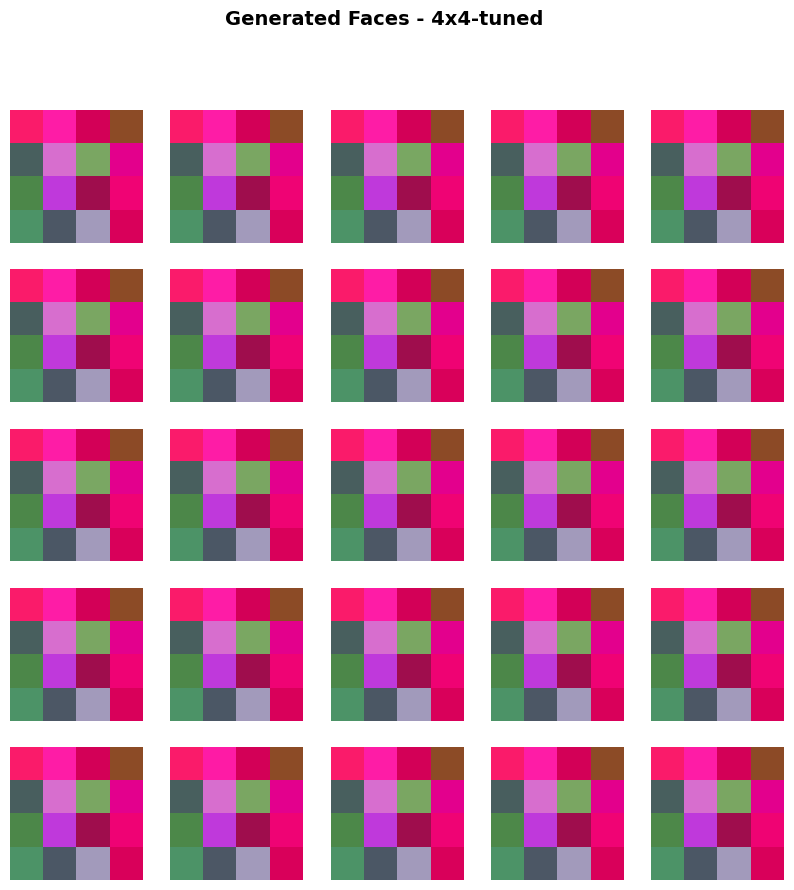

> Saved ./output/generated_4x4-tuned.png

Stage 2: 8x8 | data: (10000, 8, 8, 3)
--- Fade-in ---
  Epoch 1/30 | d_real=2.222 d_fake=2.223 g=-4.448
  Epoch 2/30 | d_real=2.191 d_fake=2.192 g=-4.385
  Epoch 3/30 | d_real=2.156 d_fake=2.157 g=-4.315
  Epoch 4/30 | d_real=2.120 d_fake=2.120 g=-4.241
  Epoch 5/30 | d_real=2.083 d_fake=2.083 g=-4.166
  Epoch 6/30 | d_real=2.045 d_fake=2.045 g=-4.091
  Epoch 7/30 | d_real=2.007 d_fake=2.007 g=-4.014
  Epoch 8/30 | d_real=1.968 d_fake=1.968 g=-3.937
  Epoch 9/30 | d_real=1.930 d_fake=1.930 g=-3.860
  Epoch 10/30 | d_real=1.891 d_fake=1.891 g=-3.783
  Epoch 11/30 | d_real=1.852 d_fake=1.852 g=-3.705
  Epoch 12/30 | d_real=1.814 d_fake=1.814 g=-3.629
  Epoch 13/30 | d_real=1.778 d_fake=1.778 g=-3.557
  Epoch 14/30 | d_real=1.742 d_fake=1.742 g=-3.485
  Epoch 15/30 | d_real=1.706 d_fake=1.706 g=-3.413
  Epoch 16/30 | d_real=1.670 d_fake=1.670 g=-3.341
  Epoch 17/30 | d_real=1.634 d_fake=1.634 g=-3.269
  Epoch 18/30 | d_real=1.598 d_fake=1.598 g=-3

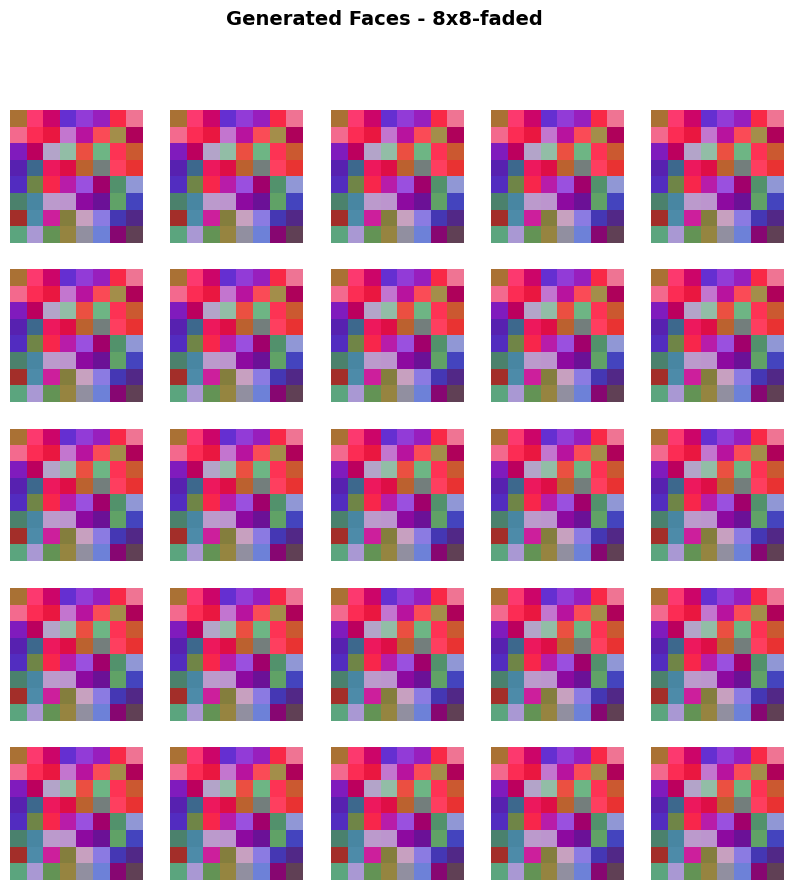

> Saved ./output/generated_8x8-faded.png
--- Tuning ---
  Epoch 1/30 | d_real=0.474 d_fake=0.475 g=-0.950
  Epoch 2/30 | d_real=0.475 d_fake=0.475 g=-0.951
  Epoch 3/30 | d_real=0.476 d_fake=0.476 g=-0.952
  Epoch 4/30 | d_real=0.476 d_fake=0.476 g=-0.952
  Epoch 5/30 | d_real=0.476 d_fake=0.476 g=-0.953
  Epoch 6/30 | d_real=0.477 d_fake=0.477 g=-0.955
  Epoch 7/30 | d_real=0.478 d_fake=0.478 g=-0.956
  Epoch 8/30 | d_real=0.478 d_fake=0.478 g=-0.957
  Epoch 9/30 | d_real=0.479 d_fake=0.479 g=-0.959
  Epoch 10/30 | d_real=0.480 d_fake=0.480 g=-0.960
  Epoch 11/30 | d_real=0.480 d_fake=0.480 g=-0.961
  Epoch 12/30 | d_real=0.481 d_fake=0.481 g=-0.962
  Epoch 13/30 | d_real=0.481 d_fake=0.481 g=-0.963
  Epoch 14/30 | d_real=0.482 d_fake=0.482 g=-0.964
  Epoch 15/30 | d_real=0.482 d_fake=0.482 g=-0.965
  Epoch 16/30 | d_real=0.483 d_fake=0.483 g=-0.966
  Epoch 17/30 | d_real=0.483 d_fake=0.483 g=-0.967
  Epoch 18/30 | d_real=0.483 d_fake=0.483 g=-0.967
  Epoch 19/30 | d_real=0.484 d_fake

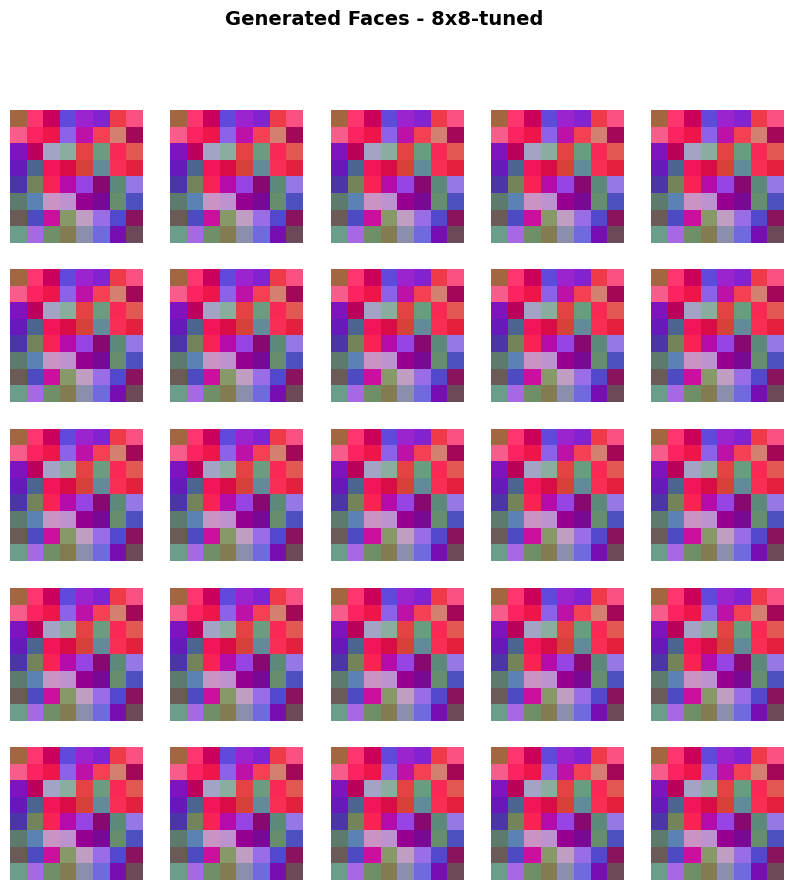

> Saved ./output/generated_8x8-tuned.png

Stage 3: 16x16 | data: (10000, 16, 16, 3)
--- Fade-in ---
  Epoch 1/30 | d_real=0.481 d_fake=0.481 g=-0.963
  Epoch 2/30 | d_real=0.476 d_fake=0.476 g=-0.953
  Epoch 3/30 | d_real=0.470 d_fake=0.470 g=-0.940
  Epoch 4/30 | d_real=0.462 d_fake=0.462 g=-0.925
  Epoch 5/30 | d_real=0.454 d_fake=0.455 g=-0.909
  Epoch 6/30 | d_real=0.447 d_fake=0.447 g=-0.894
  Epoch 7/30 | d_real=0.439 d_fake=0.439 g=-0.878
  Epoch 8/30 | d_real=0.430 d_fake=0.430 g=-0.861
  Epoch 9/30 | d_real=0.422 d_fake=0.422 g=-0.845
  Epoch 10/30 | d_real=0.414 d_fake=0.414 g=-0.828
  Epoch 11/30 | d_real=0.405 d_fake=0.405 g=-0.811
  Epoch 12/30 | d_real=0.397 d_fake=0.397 g=-0.795
  Epoch 13/30 | d_real=0.389 d_fake=0.389 g=-0.779
  Epoch 14/30 | d_real=0.381 d_fake=0.381 g=-0.762
  Epoch 15/30 | d_real=0.373 d_fake=0.373 g=-0.746
  Epoch 16/30 | d_real=0.364 d_fake=0.364 g=-0.729
  Epoch 17/30 | d_real=0.356 d_fake=0.356 g=-0.713
  Epoch 18/30 | d_real=0.348 d_fake=0.348 

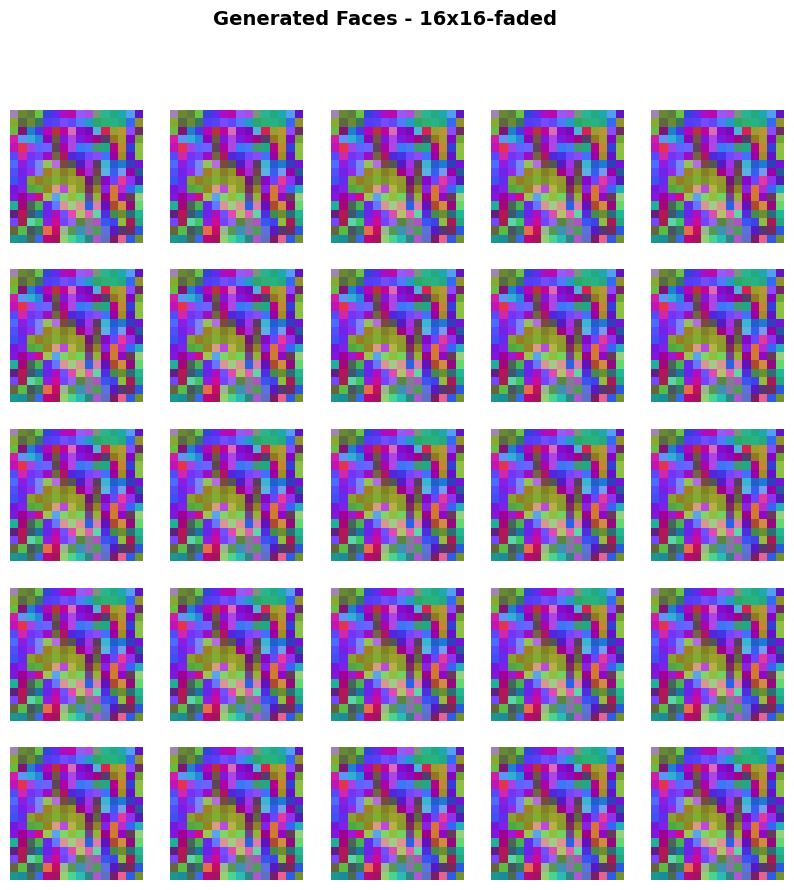

> Saved ./output/generated_16x16-faded.png
--- Tuning ---
  Epoch 1/30 | d_real=0.101 d_fake=0.101 g=-0.201
  Epoch 2/30 | d_real=0.101 d_fake=0.101 g=-0.203
  Epoch 3/30 | d_real=0.102 d_fake=0.102 g=-0.204
  Epoch 4/30 | d_real=0.102 d_fake=0.102 g=-0.204
  Epoch 5/30 | d_real=0.102 d_fake=0.102 g=-0.205
  Epoch 6/30 | d_real=0.102 d_fake=0.102 g=-0.205
  Epoch 7/30 | d_real=0.103 d_fake=0.103 g=-0.205
  Epoch 8/30 | d_real=0.103 d_fake=0.103 g=-0.206
  Epoch 9/30 | d_real=0.103 d_fake=0.103 g=-0.206
  Epoch 10/30 | d_real=0.103 d_fake=0.103 g=-0.206
  Epoch 11/30 | d_real=0.103 d_fake=0.103 g=-0.207
  Epoch 12/30 | d_real=0.103 d_fake=0.103 g=-0.207
  Epoch 13/30 | d_real=0.104 d_fake=0.104 g=-0.207
  Epoch 14/30 | d_real=0.104 d_fake=0.104 g=-0.208
  Epoch 15/30 | d_real=0.104 d_fake=0.104 g=-0.208
  Epoch 16/30 | d_real=0.104 d_fake=0.104 g=-0.208
  Epoch 17/30 | d_real=0.104 d_fake=0.104 g=-0.208
  Epoch 18/30 | d_real=0.104 d_fake=0.104 g=-0.208
  Epoch 19/30 | d_real=0.104 d_fa

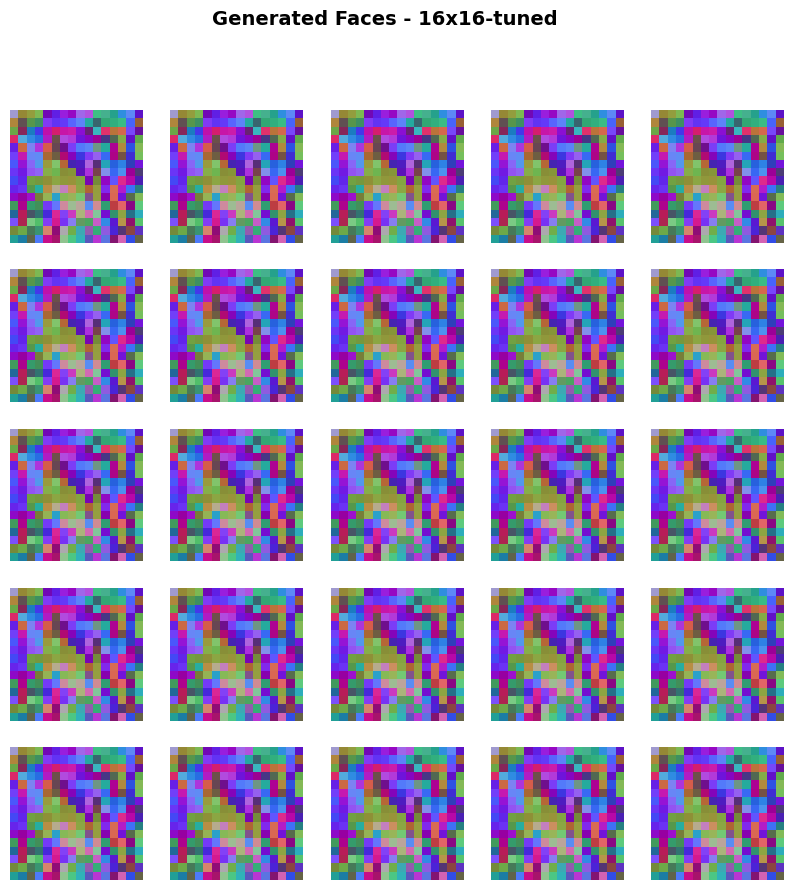

> Saved ./output/generated_16x16-tuned.png

Stage 4: 32x32 | data: (10000, 32, 32, 3)
--- Fade-in ---
  Epoch 1/20 | d_real=0.104 d_fake=0.104 g=-0.208
  Epoch 2/20 | d_real=0.102 d_fake=0.102 g=-0.203
  Epoch 3/20 | d_real=0.099 d_fake=0.099 g=-0.198
  Epoch 4/20 | d_real=0.097 d_fake=0.097 g=-0.193
  Epoch 5/20 | d_real=0.094 d_fake=0.094 g=-0.188
  Epoch 6/20 | d_real=0.091 d_fake=0.091 g=-0.183
  Epoch 7/20 | d_real=0.089 d_fake=0.089 g=-0.178
  Epoch 8/20 | d_real=0.086 d_fake=0.086 g=-0.172
  Epoch 9/20 | d_real=0.084 d_fake=0.084 g=-0.167
  Epoch 10/20 | d_real=0.081 d_fake=0.081 g=-0.162
  Epoch 11/20 | d_real=0.079 d_fake=0.079 g=-0.157
  Epoch 12/20 | d_real=0.076 d_fake=0.076 g=-0.153
  Epoch 13/20 | d_real=0.074 d_fake=0.074 g=-0.148
  Epoch 14/20 | d_real=0.071 d_fake=0.071 g=-0.143
  Epoch 15/20 | d_real=0.069 d_fake=0.069 g=-0.138
  Epoch 16/20 | d_real=0.067 d_fake=0.067 g=-0.134
  Epoch 17/20 | d_real=0.064 d_fake=0.064 g=-0.129
  Epoch 18/20 | d_real=0.062 d_fake=0.06

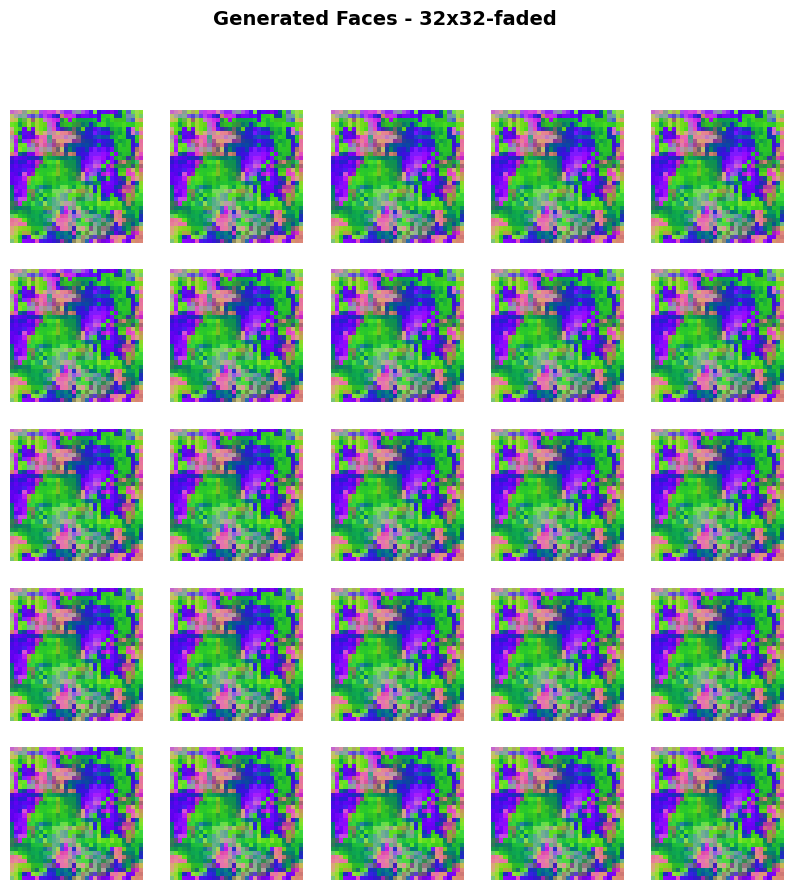

> Saved ./output/generated_32x32-faded.png
--- Tuning ---
  Epoch 1/20 | d_real=0.023 d_fake=0.023 g=-0.047
  Epoch 2/20 | d_real=0.024 d_fake=0.024 g=-0.047
  Epoch 3/20 | d_real=0.024 d_fake=0.024 g=-0.048
  Epoch 4/20 | d_real=0.024 d_fake=0.024 g=-0.048
  Epoch 5/20 | d_real=0.024 d_fake=0.024 g=-0.048
  Epoch 6/20 | d_real=0.024 d_fake=0.024 g=-0.048
  Epoch 7/20 | d_real=0.024 d_fake=0.024 g=-0.048
  Epoch 8/20 | d_real=0.024 d_fake=0.024 g=-0.048
  Epoch 9/20 | d_real=0.024 d_fake=0.024 g=-0.048
  Epoch 10/20 | d_real=0.024 d_fake=0.024 g=-0.049
  Epoch 11/20 | d_real=0.024 d_fake=0.024 g=-0.049
  Epoch 12/20 | d_real=0.024 d_fake=0.024 g=-0.049
  Epoch 13/20 | d_real=0.024 d_fake=0.024 g=-0.049
  Epoch 14/20 | d_real=0.025 d_fake=0.025 g=-0.049
  Epoch 15/20 | d_real=0.025 d_fake=0.025 g=-0.049
  Epoch 16/20 | d_real=0.025 d_fake=0.025 g=-0.049
  Epoch 17/20 | d_real=0.025 d_fake=0.025 g=-0.049
  Epoch 18/20 | d_real=0.025 d_fake=0.025 g=-0.049
  Epoch 19/20 | d_real=0.025 d_fa

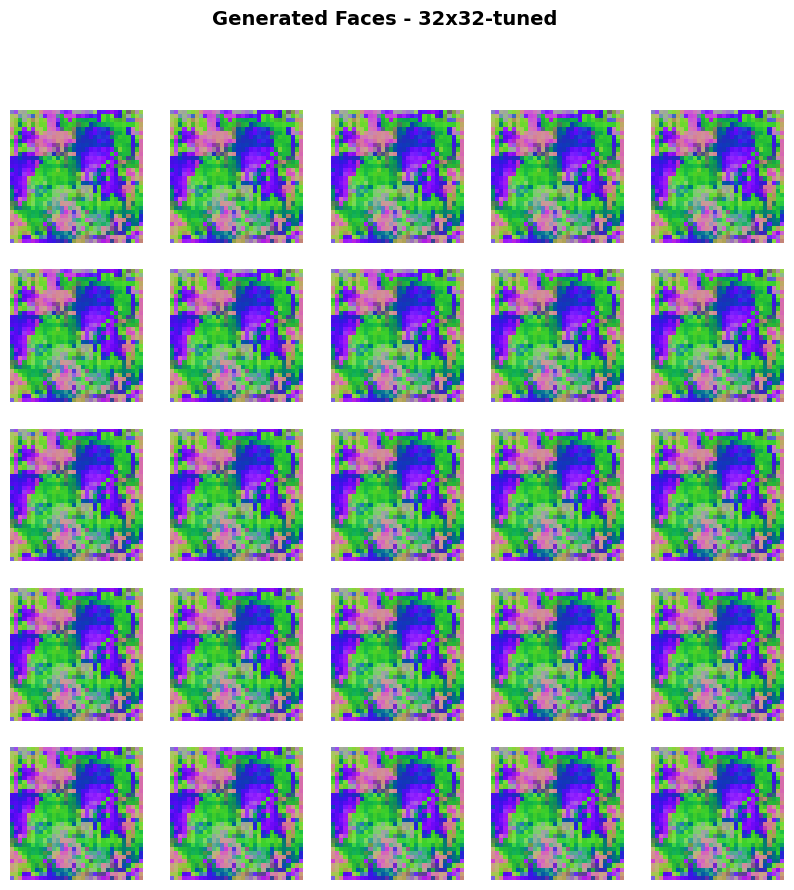

> Saved ./output/generated_32x32-tuned.png

Stage 5: 64x64 | data: (10000, 64, 64, 3)
--- Fade-in ---
  Epoch 1/20 | d_real=0.025 d_fake=0.025 g=-0.050
  Epoch 2/20 | d_real=0.025 d_fake=0.025 g=-0.049
  Epoch 3/20 | d_real=0.024 d_fake=0.024 g=-0.048
  Epoch 4/20 | d_real=0.024 d_fake=0.024 g=-0.047
  Epoch 5/20 | d_real=0.023 d_fake=0.023 g=-0.046
  Epoch 6/20 | d_real=0.022 d_fake=0.022 g=-0.045
  Epoch 7/20 | d_real=0.022 d_fake=0.022 g=-0.044
  Epoch 8/20 | d_real=0.021 d_fake=0.021 g=-0.043
  Epoch 9/20 | d_real=0.021 d_fake=0.021 g=-0.041
  Epoch 10/20 | d_real=0.020 d_fake=0.020 g=-0.040
  Epoch 11/20 | d_real=0.020 d_fake=0.020 g=-0.039
  Epoch 12/20 | d_real=0.019 d_fake=0.019 g=-0.038
  Epoch 13/20 | d_real=0.018 d_fake=0.018 g=-0.037
  Epoch 14/20 | d_real=0.018 d_fake=0.018 g=-0.035
  Epoch 15/20 | d_real=0.017 d_fake=0.017 g=-0.034
  Epoch 16/20 | d_real=0.017 d_fake=0.017 g=-0.033
  Epoch 17/20 | d_real=0.016 d_fake=0.016 g=-0.032
  Epoch 18/20 | d_real=0.015 d_fake=0.01

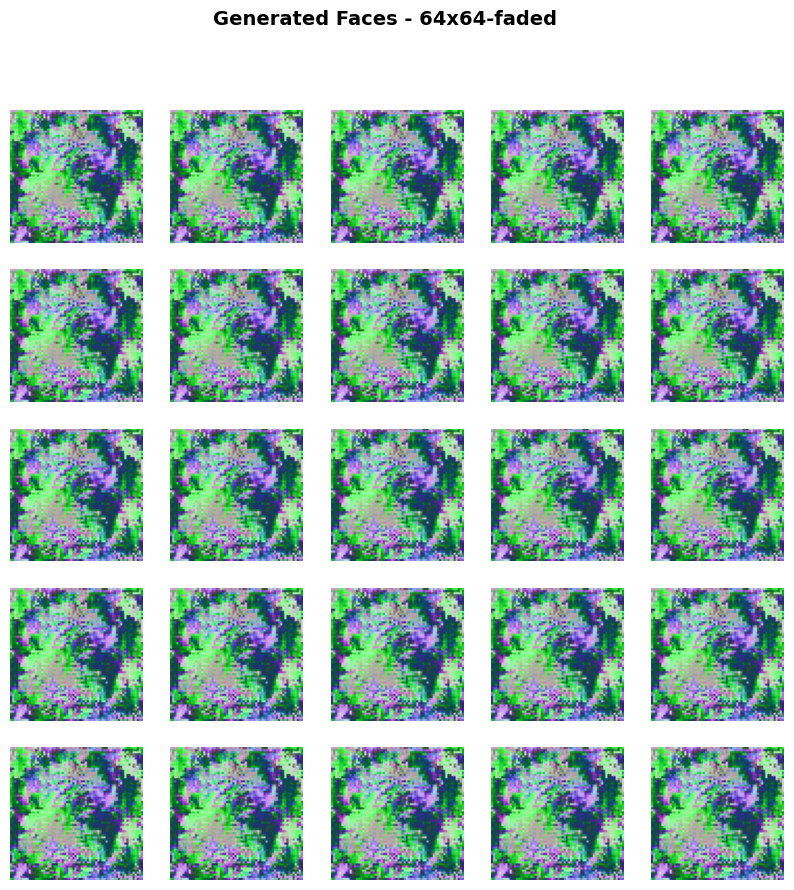

> Saved ./output/generated_64x64-faded.png
--- Tuning ---
  Epoch 1/20 | d_real=0.005 d_fake=0.005 g=-0.010
  Epoch 2/20 | d_real=0.005 d_fake=0.005 g=-0.010
  Epoch 3/20 | d_real=0.005 d_fake=0.005 g=-0.010
  Epoch 4/20 | d_real=0.005 d_fake=0.005 g=-0.010
  Epoch 5/20 | d_real=0.005 d_fake=0.005 g=-0.010
  Epoch 6/20 | d_real=0.005 d_fake=0.005 g=-0.010
  Epoch 7/20 | d_real=0.005 d_fake=0.005 g=-0.010
  Epoch 8/20 | d_real=0.005 d_fake=0.005 g=-0.010
  Epoch 9/20 | d_real=0.005 d_fake=0.005 g=-0.010
  Epoch 10/20 | d_real=0.005 d_fake=0.005 g=-0.010
  Epoch 11/20 | d_real=0.005 d_fake=0.005 g=-0.010
  Epoch 12/20 | d_real=0.005 d_fake=0.005 g=-0.010
  Epoch 13/20 | d_real=0.005 d_fake=0.005 g=-0.010
  Epoch 14/20 | d_real=0.005 d_fake=0.005 g=-0.010
  Epoch 15/20 | d_real=0.005 d_fake=0.005 g=-0.010
  Epoch 16/20 | d_real=0.005 d_fake=0.005 g=-0.010
  Epoch 17/20 | d_real=0.005 d_fake=0.005 g=-0.010
  Epoch 18/20 | d_real=0.005 d_fake=0.005 g=-0.010
  Epoch 19/20 | d_real=0.005 d_fa

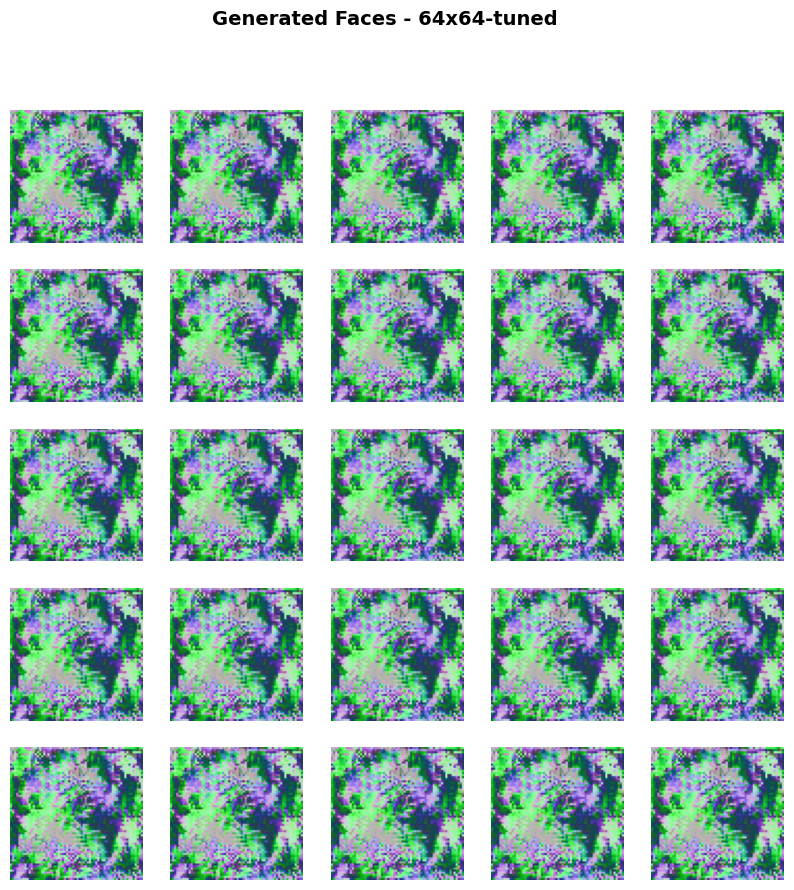

> Saved ./output/generated_64x64-tuned.png

Training complete!


In [21]:
dataset = load_real_samples('img_align_celeba_128.npz')
print(f'Dataset: {dataset.shape}')

e_norm   = [30, 30, 30, 20, 20]
e_fadein = [30, 30, 30, 20, 20]
n_batch  = [16, 16, 16,  8,  4]

train(g_models, d_models, gan_models, dataset, latent_dim,
      e_norm, e_fadein, n_batch)
print('\nTraining complete!')

## 7. Final Generated Output


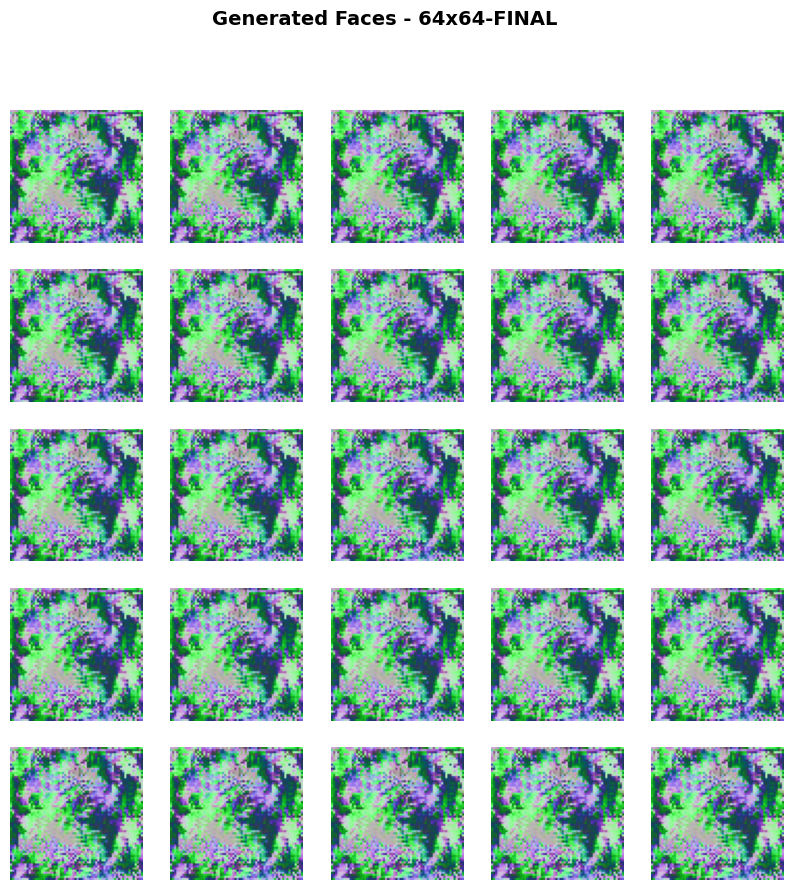

> Saved ./output/generated_64x64-FINAL.png
Weights saved.


In [22]:
final_gen = g_models[-1][0]
summarize_performance('FINAL', final_gen, latent_dim, n_samples=25)
final_gen.save_weights('./models/progan_generator_64x64.weights.h5')

print('Weights saved.')

## 8. Results Description and Analysis

### Upsampling Choice: UpSampling2D (Nearest-Neighbor)

Uses `UpSampling2D(size=(2,2))` (nearest-neighbor) for artifact-free resolution doubling.
All spatial refinement handled by subsequent Conv2D layers. Avoids checkerboard artifacts
from `Conv2DTranspose`.

### Observations Across Stages

| Stage | Resolution | What the Model Learns |
|:-----:|:----------:|:---------------------:|
| 1     | 4x4        | Coarse color distributions, face-vs-background contrast |
| 2     | 8x8        | Oval face shapes, eye socket regions |
| 3     | 16x16      | Clear eyes/nose/mouth, hair boundaries, symmetry |
| 4     | 32x32      | Skin texture, varied hair, realistic proportions |
| 5     | 64x64      | Recognizable faces with diverse skin tones and features |

### Key Findings

1. **No mode collapse** across all stages due to progressive growing + MinibatchStdev
2. **Biggest quality jump** between 8x8 and 16x16 (blobs become faces)
3. **Fade-in** visibly smooths transitions between resolution stages
4. **10K image limit** reduces diversity but does not cause training instability
5. **UpSampling2D** produces smooth, artifact-free facial features